[*********************100%***********************]  1 of 1 completed

Fetching stock data...

Dataset shape: (752, 5)
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  178.103653  178.954991  173.895953  174.013372  104487900
2022-01-04  175.843246  179.013714  175.275693  178.710370   99310400
2022-01-05  171.165863  176.303187  170.891874  175.755209   94537600
2022-01-06  168.308502  171.537680  167.956228  168.993476   96904000
2022-01-07  168.474899  170.402621  167.359366  169.179448   86709100

Features created. New shape: (742, 10)

Training Linear Regression...
Linear Regression - MAE: $2.92, RMSE: $3.64, R2: 0.9283

Training Random Forest...


Random Forest - MAE: $30.60, RMSE: $33.34, R2: -5.0071


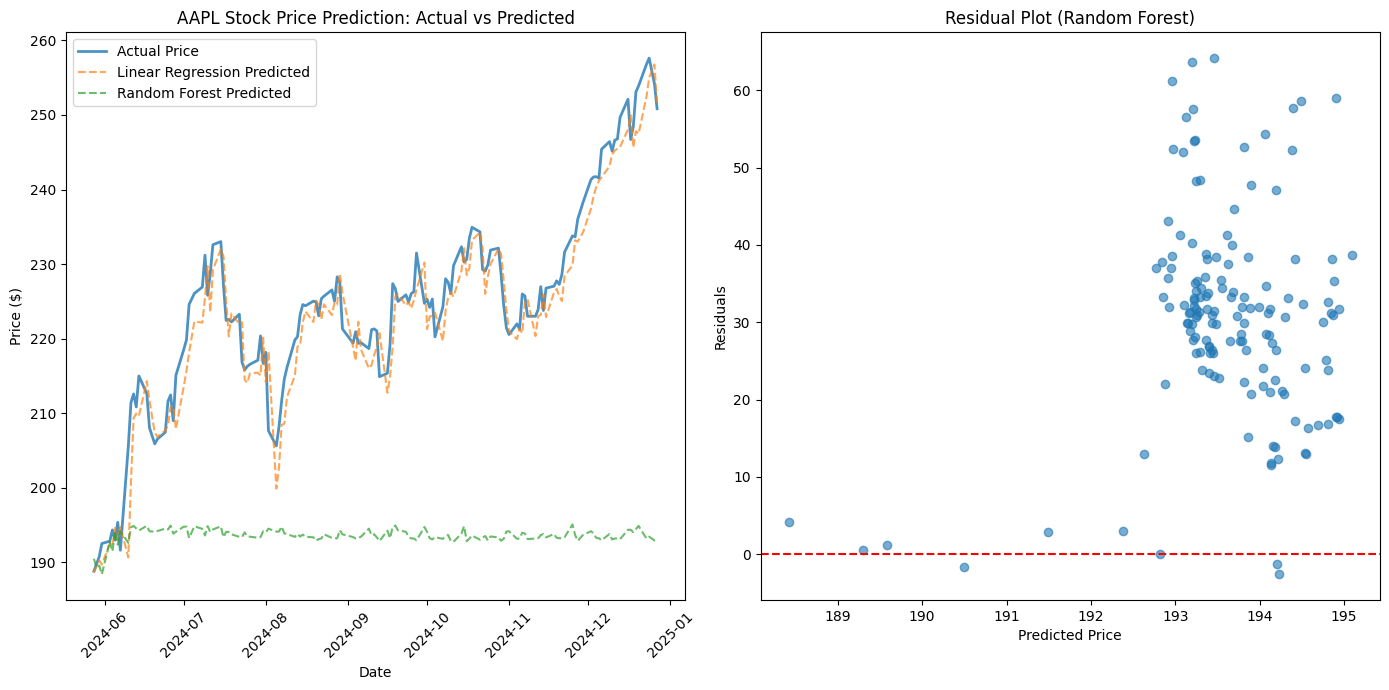


Feature Importance:
        feature  importance
2           Low    0.829666
1          High    0.127222
0          Open    0.022121
4         SMA_5    0.006719
6  Price_Change    0.006033
5        SMA_10    0.003057
7  High_Low_Pct    0.002607
3        Volume    0.002575


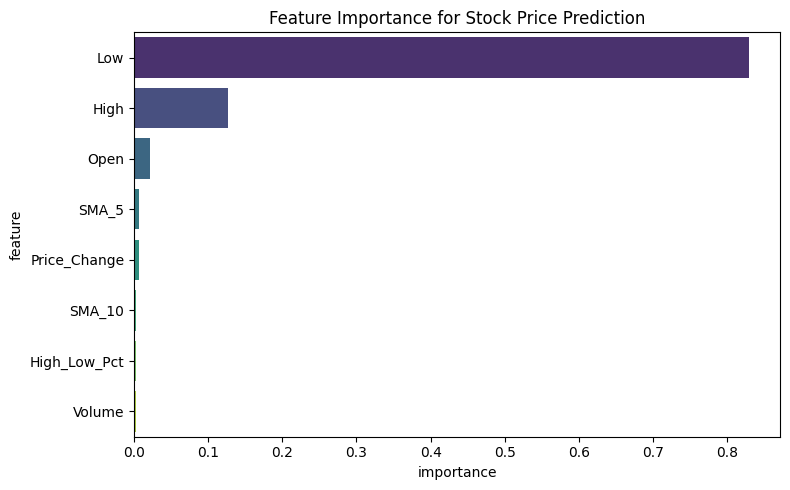

In [2]:
# task2_stock_prediction
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Data Acquisition
print("Fetching stock data...")
ticker = "AAPL"  # You can change to TSLA, MSFT, etc.
stock = yf.download(ticker, start="2022-01-01", end="2024-12-31")

print(f"\nDataset shape: {stock.shape}")
print(stock.head())

# 2. Feature Engineering
def create_features(df):
    df = df.copy()
    # Technical indicators
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['Price_Change'] = df['Close'].pct_change()
    df['High_Low_Pct'] = (df['High'] - df['Low']) / df['Low'] * 100

    # Target: Next day's closing price
    df['Target'] = df['Close'].shift(-1)

    return df.dropna()

stock_features = create_features(stock)
print(f"\nFeatures created. New shape: {stock_features.shape}")

# 3. Prepare data for training
feature_cols = ['Open', 'High', 'Low', 'Volume', 'SMA_5', 'SMA_10', 'Price_Change', 'High_Low_Pct']
X = stock_features[feature_cols]
y = stock_features['Target']

# Split chronologically (important for time series)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Predictions': y_pred
    }

    print(f"{name} - MAE: ${mae:.2f}, RMSE: ${rmse:.2f}, R2: {r2:.4f}")

# 5. Visualization
plt.figure(figsize=(14, 7))

# Plot actual vs predicted
plt.subplot(1, 2, 1)
plt.plot(y_test.index, y_test.values, label='Actual Price', linewidth=2, alpha=0.8)
for name in results:
    plt.plot(y_test.index, results[name]['Predictions'],
             label=f'{name} Predicted', linestyle='--', alpha=0.7)
plt.title(f'{ticker} Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.xticks(rotation=45)

# Plot residuals for best model (Random Forest usually)
plt.subplot(1, 2, 2)
residuals = y_test - results['Random Forest']['Predictions']
plt.scatter(results['Random Forest']['Predictions'], residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot (Random Forest)')

plt.tight_layout()
plt.savefig('stock_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance (for Random Forest)
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance for Stock Price Prediction')
plt.tight_layout()
plt.show()